In [1]:
import numpy as np
import pandas as pd
import os
import arviz as az

from MonoTools.MonoTools import fit, tools, lightcurve

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


# The lightcurve

Let's download the target lightcurve using the attached `lightcurve` module



In [2]:
tic=103095888
lc=lightcurve.multilc(tic,'tess',save=False)

Getting all IDs
Accessing online catalogues to match ID to RA/Dec (may be slow) mission= tess
92 90
Sector 92 not (yet) found on MAST | RESPONCE:404
['/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-45_qlplc.h5', '/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-46_qlplc.h5']
['/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-165_qlplc.h5', '/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-166_qlplc.h5']
['/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-179_qlplc.h5', '/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-180_qlplc.h5']
None


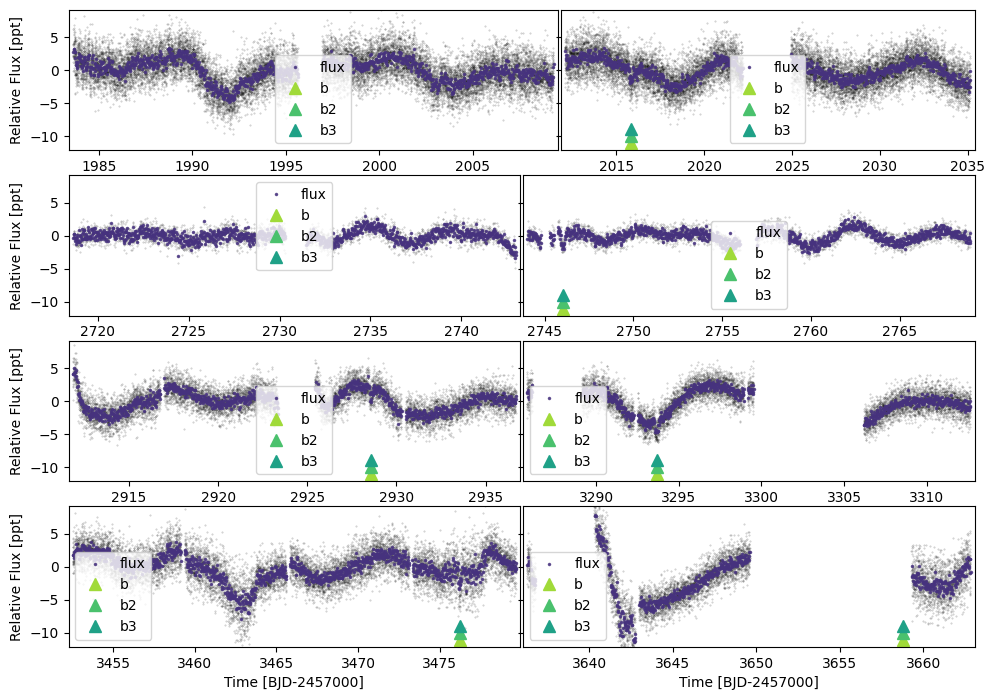

In [4]:
lc.remove_binned_arrs()
lc.plot(timeseries=['flux'],plot_ephem={'b':{'p':(2746.02021-2015.81701)/4,'t0':2746.02021},
                    'b2':{'p':(2746.02021-2015.81701)/8,'t0':2746.02021},
                    'b3':{'p':(2746.02021-2015.81701)/20,'t0':2746.02021}},savepng=False)

### Cleaning up

Due to some scattered light, there's a couple of very noise regions, which we can mask by updating the `lc.mask` array:

(In fact, these are pre-removed on the above plot)

In [3]:
lc.mask[abs(lc.time-3654.5)<4.8]=False
lc.mask[abs(lc.time-3638.5)<1.75]=False

# Initialising the model

Here, let's start the model using the TIC id, and passing it the mission (`tess`) and the lightcurve from above.

We can also initialise the stellar parameters. Without any argument, it uses the TICv8 parameters from the TESS Input Catalogue and stored in the `lc` class.

We can also initialise the planet. Here we use `add_ambiguous` as it is a planet with multiple transits, but an ambiguous period. Other options are `add_multi` (for a normal planet with multiple transits), `add_mono` (for a single transit) and `add_duo` (for the unique case of an ambiguous period due to two transits).

To add the planets, you typically need to provide the transit time (or times), the duration (`tdur`) and the depth (as a ratio).

In [35]:
mod = fit.monoModel(tic, 'tess', lc=lc)
mod.init_starpars()
mod.add_ambiguous({'tcens':[2015.81701,
                            np.random.normal(2746.02021,0.015),
                            np.random.normal(2928.57101,0.015),
                            np.random.normal(3293.67261,0.015),
                            3476.22341],
                   'tdur':10/48,'depth':1.8e-3},'b')

{'tcens': array([2015.81701   , 2746.03670605, 2928.5610425 , 3293.66789473,
       3476.22341   ]), 'tdur': 0.20833333333333334, 'depth': 0.0018, 'span': 1460.4064, 'maxperiod_pair': 1, 'maxperiod': 182.5508, 'p_ratios': array([[[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 4.,  8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48.]],

       [[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.]],

       [[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 7., 14., 21., 28., 35., 42., 49., 56., 63., 70., 77., 84.]],

       [[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.]]]), 'period': 182.5508, 'period_err': 0.034708333333333334, 'period_int_aliases': array([ 8., 16., 24., 32., 40.])}


# Initialising the lightcurve

There are two main options - with or without a Gaussian Process. 

Without a Gaussian Process (`use_GP=False`) will use a bspline-fitting method (masking the identified transits). This will be faster, but in cases with relatively high-amplitude noise/stellar activity close in duration to the transit, a GP will be more robust. In this case, we do not need all of the data, so we can cut the out-of-transit data, here to 2.5 transit durations from t0, using `cut_distance=2.5`.

In the case of `use_GP=True`, `bin_oot=True` allows for photometry far-from-transit to be binned in order to speed up computation time. Alternatively, `bin_all=True` will bin all the data including in-transit points. Alternatively `fit_no_flatten=True` will not perform any flattening and assume the lightcurve is already flat with out-of-transit flux at ~0.0.

In [36]:
mod.init_lc(use_GP=False, bin_oot=False, cut_distance=2.5)

[1983.62416643 1996.90862852 2718.63204381 2910.26369667 3285.79832652
 3306.19398793 3452.5326003  3636.2596023 ] [1995.6308658  2035.13108161 2768.97249076 2936.68960795 3303.73569416
 3312.64986176 3479.67162956 3662.82915624]


# Initialising the model

There are many options for model fitting:
- `constrain_LD=True` will constrain the limb darkening coefficients to the theoretical values
- `ld_mult=3`. This is the multiplication factor for the theoretical LD params (to account for systematic errors)
- `model_jitter=True` will model a log jitter term for each lightcurve (split into cadences)
- `model_phot_mean=True` will model a mean photometric term for each lightcurve (split into cadences)
- `timing_sigma=0.1` allows the adjustment of the priors on the t0s. The default is to assume they are known to ±0.1tdur.
- `floattype=np.float64` can be adjusted to e.g. `np.float32` to attempt to speed up the model.
- `step_initialise=True` will optimize the model in steps, starting with the most sensitive transit parameters. This is preferred.
- `use_L2=False`. If set to `True`, the model will fit for unincluded "second light" (i.e. contamination)
- `model_ambig_ttv=False`. If set to `True`, the model does not assume a linear ephemeris for these multiple transits, but includes TTVs.

In [37]:
mod.init_model(constrain_LD=True,model_jitter=True,model_phot_mean=True)

[1983.62416643 1996.90862852 2718.63204381 2910.26369667 3285.79832652
 3306.19398793 3452.5326003  3636.2596023 ] [1995.6308658  2035.13108161 2768.97249076 2936.68960795 3303.73569416
 3312.64986176 3479.67162956 3662.82915624]
Initialising ~FAST~ MonoTools model.
initialised planet info
Shape.0
Initialised everything. Optimizing


### Plotting the initial model:

The models are interpolated to the full input lightcurve and stored in `mod.trans_to_plot` and `mod.gp_to_plot`.

Additionally, `interactive=True` may produce an interactive Bokeh plot in the browser.

initialising transit
Initalising Transit models for plotting with n_samp= 10
phase (1349,) masked_flux 1349 cad_mask 44161 34000 phasebool (44161,) 1350 transmod (1349,) othpls [0. 0. 0. ... 0. 0. 0.] (1349,)
(726,) (726,) (726,) (726,) (726,)
(1349,) (1349,) (1349,) (1349,) (1349,)
(123,) (123,) (123,) (123,) (123,)
0.34290674778914143


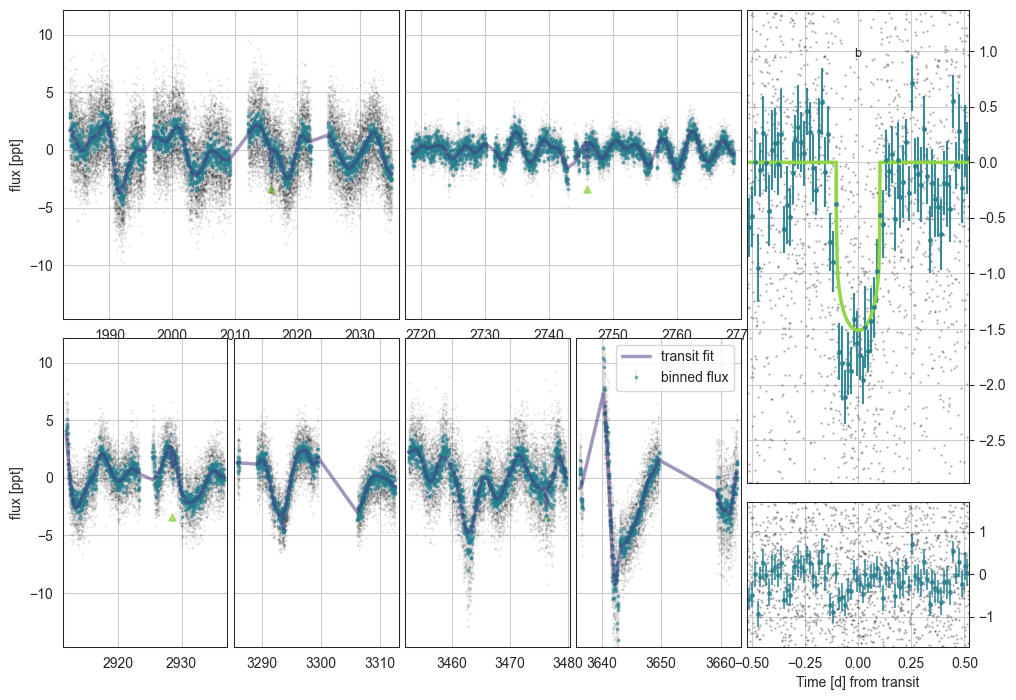

In [17]:
mod.plot()

# Sampling

The sampling can be modified in the following ways:
- `n_draws=1800` is the number of (post-burn-in) samples per chain
- `n_chains=6` is the number of chains
- `cores=6` is the number of CPU cores to run on.
- `sample_method=pm.NUTS` allows for the ability to run pymc samplers

In [56]:
mod.sample_model(overwrite=True,cores=6,n_draws=1800,sample_method=pm.NUTS)

Multiprocess sampling (4 chains in 6 jobs)
NUTS: [Rs, rhostar, t0_b_0, t0_b_4, logror_b, b_b, tdur_b, q_star_tess, log_jitter_ts_120, phot_mean_ts_120, log_jitter_ts_200, phot_mean_ts_200, log_jitter_ts_600, phot_mean_ts_600]


Sampling 4 chains for 1_188 tune and 1_800 draw iterations (4_752 + 7_200 draws total) took 1212 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saving sampled model parameters to file with shape:  (27, 14)


### Checking the outputs

Some options are:
- Using `arviz` to plot the chains
- Using `mod.plot_corner` to produce corner plots for the planet parameters
- Using `mod.plot()`

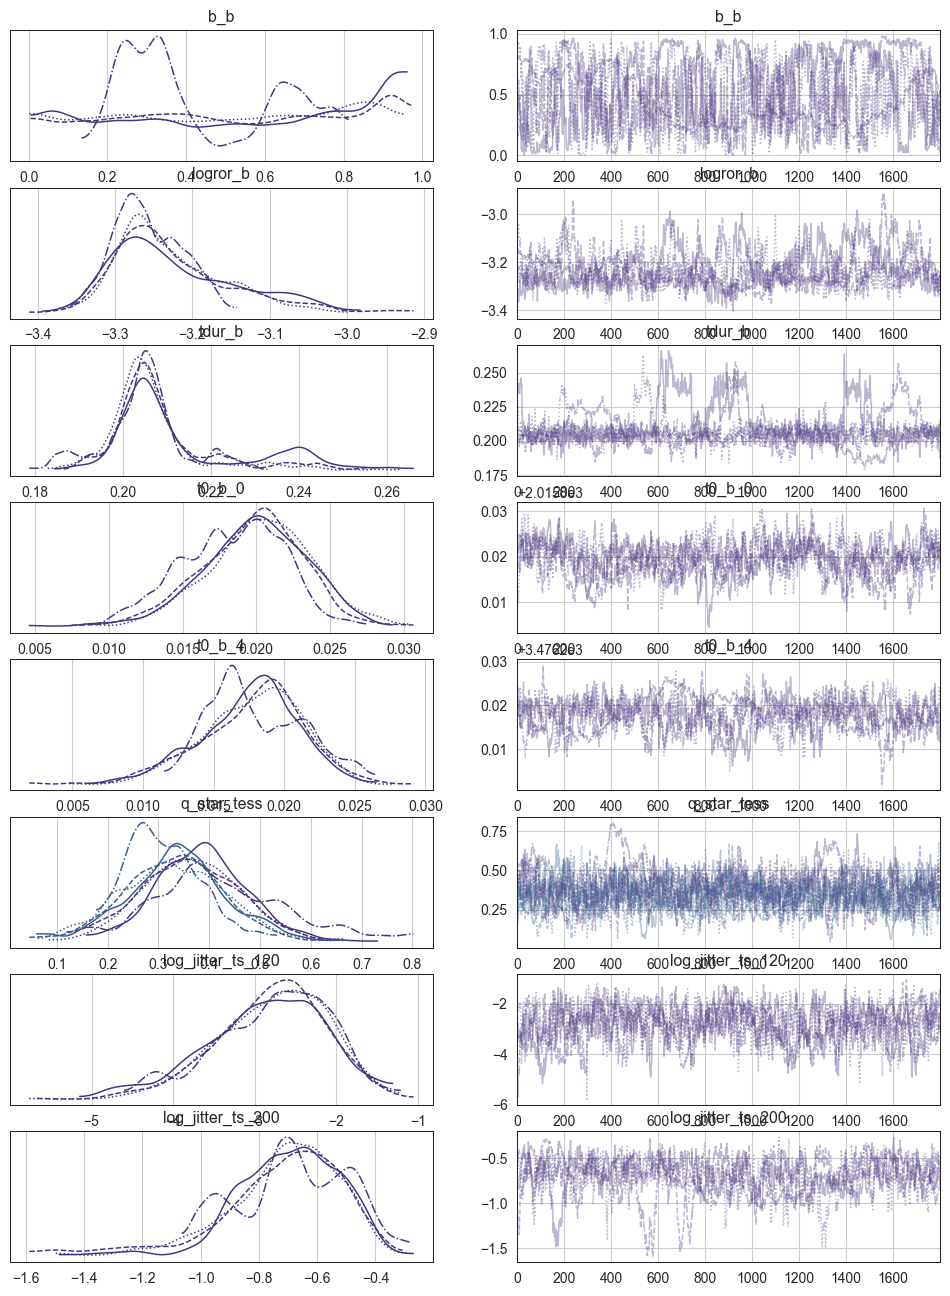

In [58]:
_=az.plot_trace(mod.trace['posterior'], var_names=['b_b','logror_b','tdur_b','t0_b_0','t0_b_4','q_star_tess','log_jitter_ts_120','log_jitter_ts_200'])

variables for Corner: ['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b']
['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b']


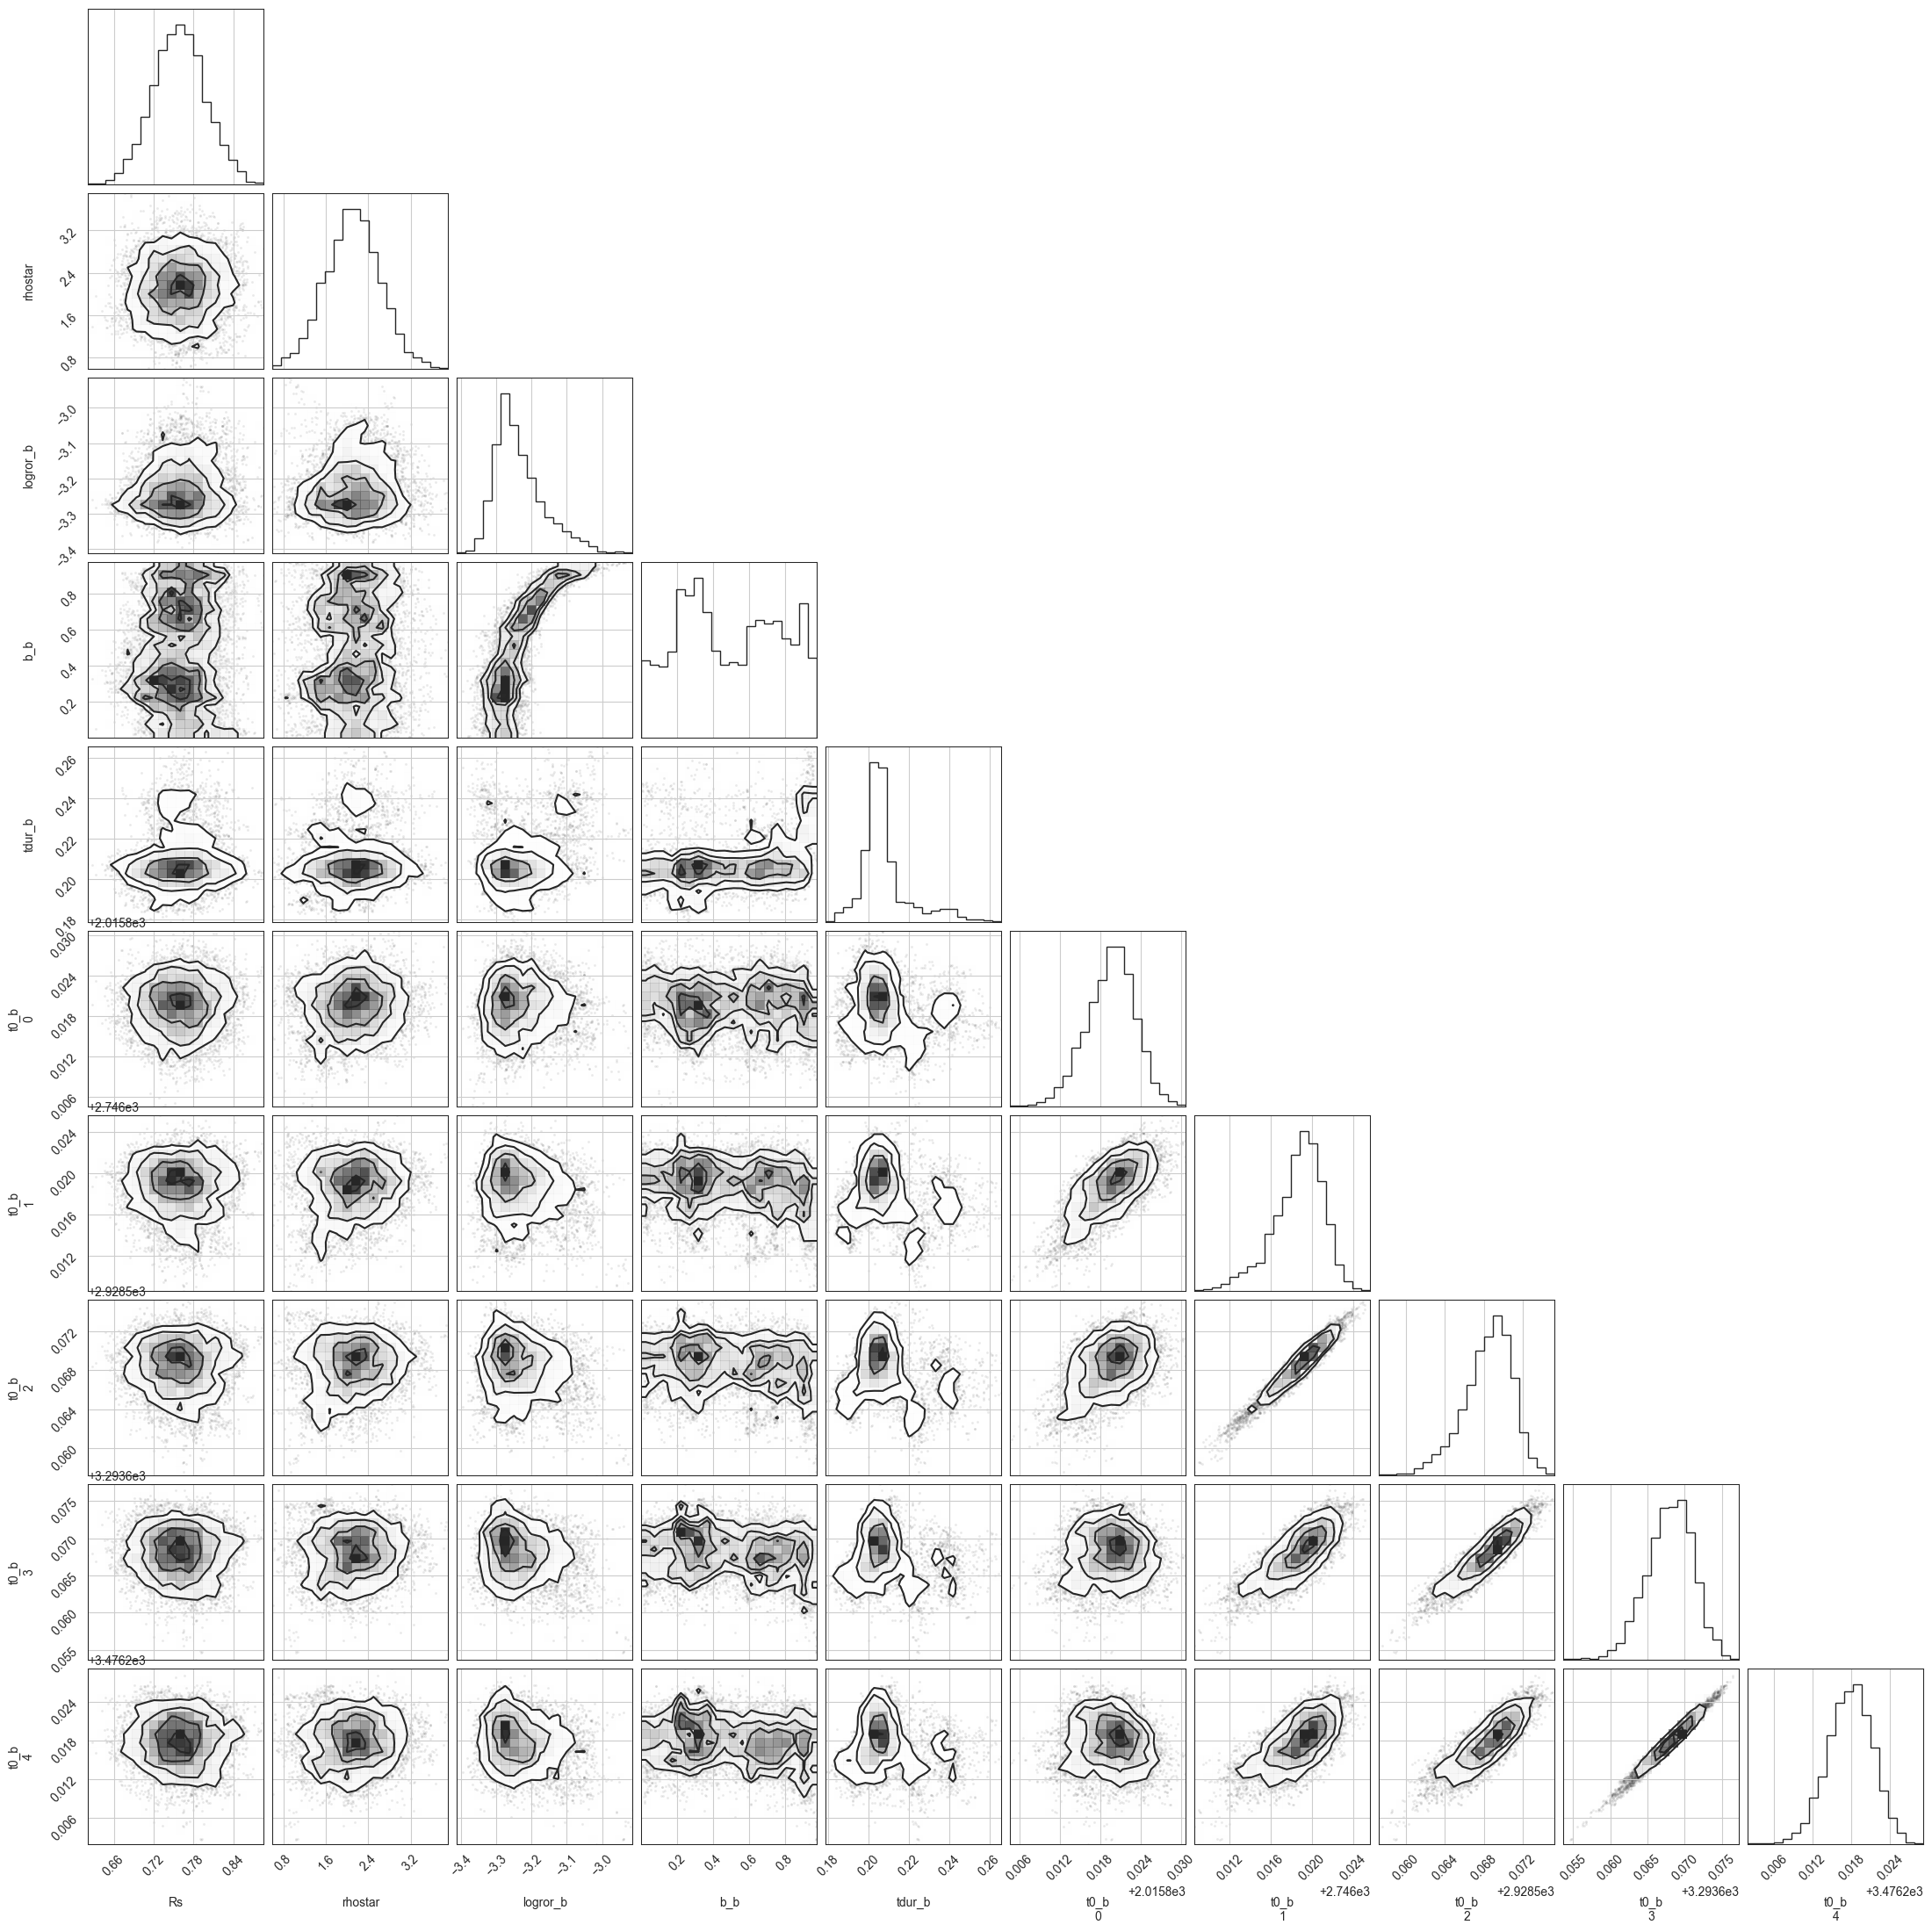

In [59]:
mod.plot_corner()

initialising transit
Initalising Transit models for plotting with n_samp= 990
phase (1349,) masked_flux 1349 cad_mask 44161 34000 phasebool (44161,) 1350 transmod (1349,) othpls [0. 0. 0. ... 0. 0. 0.] (1349,)
(726,) (726,) (726,) (726,) (726,)
(1349,) (1349,) (1349,) (1349,) (1349,)
(123,) (123,) (123,) (123,) (123,)
0.4763927189622087


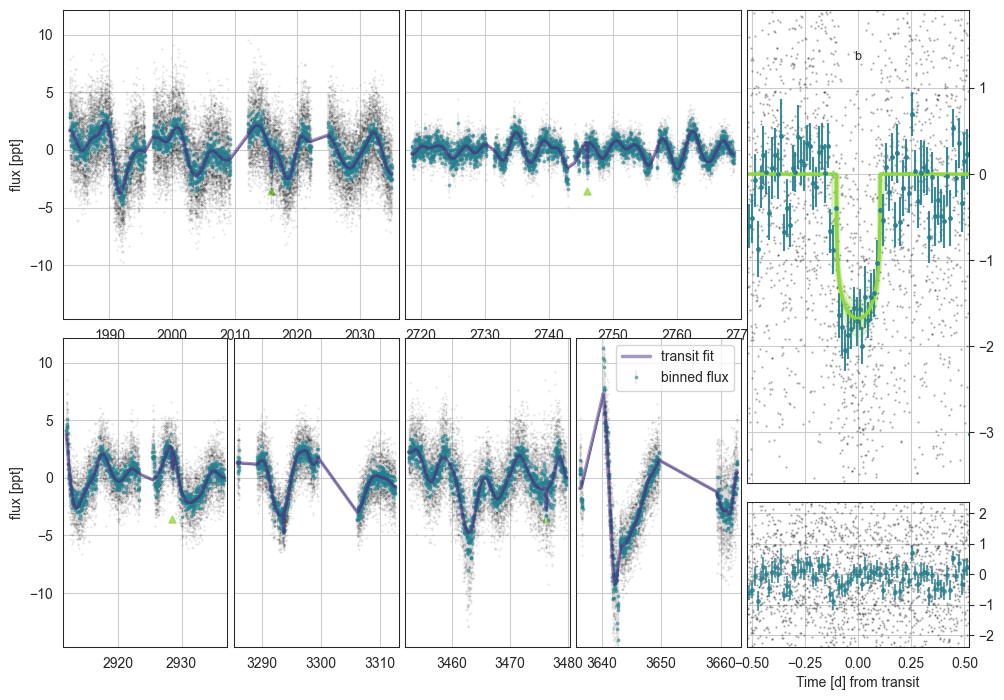

In [60]:
mod.plot()

# Computing the period probabilities _a posteriori_

In this new version, we fit the transits in a way ambivalent to the periods, and instead only assess the period probabilities using the trace (and various priors). To do this, you have to call `mod.assess_period_from_posterior()`

### Eccentricity priors
At this point, key choices have to be made about the eccentricity prior by updating `ecc_prior='auto'`. This is extremely important, as *the uncertainty in your derived period distribution depends highly on the eccentricity prior*, so choose an option that you believe best matches your planet/planetary system. There are the following options:
- `ecc_prior='uniform'` - Planets don't have this distribution in reality. Don't use this. 
- `ecc_prior='kipping'` - The (close-in) Kipping 2013 prior. Derived from RV planets, and therefore dominated by high-mass planets. Potentially OK in those cases.
- `ecc_prior='vaneylen'` - Specifically the multi-planet version derived in VanEylen 2018. Measured for compact multi systems in Kepler. The most e=0-biased prior available (therefore, potentially, the best period logprob constraints)
- `ecc_prior='bernmodel_sing'` - Derived from single planets as produced by Bern model full-system simulations. No observational biases. The Bern Model priors are also all radius-dependent using the initial radius to choose one distribution from [terrestrials, Neptunians or Giants]. The giant case matches `kipping` well, while the smaller planets are much more low-eccentricity.
- `ecc_prior='bernmodel_mult'` - Derived from multi systems produced by Bern model. Radius-dependent (rocky, Neptunian & Giants). These, especially for small planets, are well-constrained to e~0 (though less so than `vaneylen`).
- `ecc_prior='bernmodel_both'` - Derived from all (observable) planets as produced by Bern model full-system simulations.
- `ecc_prior='auto'` - The default is the (radius-constrained) `bernmodel_both` prior for single cases (as we do not know if there could be additional planets), and the `bernmodel_mult` in multi cases.

In [61]:
mod.assess_period_from_posterior()

both__bernmodel auto {'kipping': 'kip', 'vaneylen': 'vve', 'flat': 'flat', 'apogee': 'apo', 'bernmodel_both': 'both__bernmodel', 'bernmodel_sing': 'singles__bernmodel', 'bernmodel_mult': 'multis__bernmodel', 'auto': 'both__bernmodel'} both ['bern', 'auto']


### Viewing the derived parameters

`mod.make_table()` creates (and saves) the posterior statistics. Check that `ess` is at least a thousand, and `r_hat` is well below 1.05 (ideally below 1.01).

In [62]:
df=mod.make_table()
df.shape

Saving sampled model parameters to file with shape:  (84, 14)


(84, 14)

In [64]:
df.iloc[:42]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
Rs,0.75914,0.03932,0.68555,0.83545,0.00245,0.00173,256.57139,554.02383,1.01865,0.69458,0.72013,0.75909,0.79827,0.82624
rhostar,2.11344,0.51435,1.10447,3.04547,0.04724,0.03348,118.95985,376.04896,1.03987,1.26015,1.58644,2.11278,2.62271,2.95344
t0_b_0,2015.81954,0.00361,2015.81227,2015.82586,0.00033,0.00023,125.08518,257.33884,1.02911,2015.81328,2015.81581,2015.81980,2015.82304,2015.82509
t0_b_4,3476.21778,0.00349,3476.21136,3476.22438,0.00036,0.00026,88.44852,137.51605,1.01490,3476.21187,3476.21431,3476.21795,3476.22126,3476.22334
logror_b,-3.23370,0.07041,-3.34304,-3.08708,0.00847,0.00602,63.27842,220.54433,1.05399,-3.32226,-3.29658,-3.24998,-3.16546,-3.09006
tdur_b,0.20825,0.01245,0.18952,0.24084,0.00180,0.00128,71.90059,76.25026,1.05726,0.19292,0.19962,0.20544,0.21631,0.23811
log_jitter_ts_120,-2.79781,0.68822,-4.13588,-1.55716,0.04692,0.03323,219.00424,406.19278,1.00444,-4.06133,-3.50086,-2.73259,-2.11362,-1.76882
phot_mean_ts_120,0.04083,0.06181,-0.07512,0.15919,0.00378,0.00271,264.65389,706.43017,1.05399,-0.05565,-0.02056,0.03736,0.10405,0.14691
log_jitter_ts_200,-0.70331,0.19710,-1.05629,-0.38840,0.02013,0.01428,91.36896,203.54593,1.02845,-1.02964,-0.88988,-0.68422,-0.50974,-0.43137
phot_mean_ts_200,-0.03908,0.03345,-0.10012,0.02480,0.00245,0.00174,182.38262,595.42982,1.03133,-0.09161,-0.07126,-0.04087,-0.00661,0.01730


In [66]:
df.iloc[42:]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
min_ecc_b[3],0.21145,0.19519,0.00010,0.63451,0.02044,0.01549,124.39393,126.64398,1.04204,0.01330,0.03818,0.14673,0.41299,0.65476
min_ecc_b[4],0.24113,0.20948,0.00010,0.67686,0.02569,0.01824,76.78674,126.64398,1.04760,0.01379,0.04555,0.17595,0.47223,0.69521
omega_b[0],2.03374,1.11366,1.57080,4.71239,0.11966,0.08490,86.61159,86.61159,1.04865,1.57080,1.57080,1.57080,1.57080,4.71239
omega_b[1],2.55996,1.45925,1.57080,4.71239,0.15679,0.11124,86.62023,86.62023,1.04477,1.57080,1.57080,1.57080,4.71239,4.71239
omega_b[2],3.11236,1.57063,1.57080,4.71239,0.18873,0.13402,69.25912,69.25912,1.04583,1.57080,1.57080,1.57080,4.71239,4.71239
omega_b[3],3.64774,1.48712,1.57080,4.71239,0.19192,0.13637,60.04177,60.04177,1.05496,1.57080,1.57080,4.71239,4.71239,4.71239
omega_b[4],4.14298,1.21030,1.57080,4.71239,0.14629,0.10389,68.44742,68.44742,1.04141,1.57080,1.57080,4.71239,4.71239,4.71239
perprior_b[0],-4.29182,0.00001,-4.29184,-4.29180,0.00000,0.00000,171.82602,391.00644,1.02377,-4.29184,-4.29183,-4.29182,-4.29181,-4.29180
perprior_b[1],-2.44343,0.00001,-2.44345,-2.44341,0.00000,0.00000,171.82602,391.00644,1.02377,-2.44344,-2.44344,-2.44343,-2.44342,-2.44341
perprior_b[2],-1.36219,0.00001,-1.36221,-1.36217,0.00000,0.00000,171.82602,391.00644,1.02377,-1.36220,-1.36220,-1.36219,-1.36218,-1.36217


# Plotting the periods

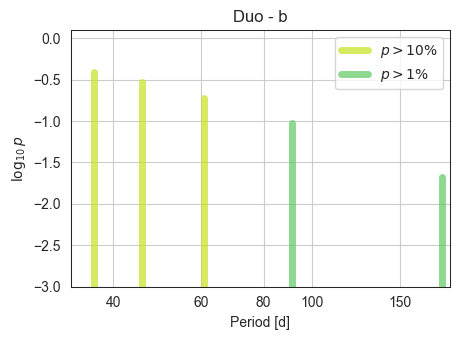

In [72]:
mod.plot_periods(ymin=-3)

# Saving

This will save all class variables in a pickle, and the trace in a .nc file

In [73]:
mod.save_model_to_file()

{0: {'start': 1983.6297218556767, 'end': 2035.1310816138769, 'cadname': 'ts_120'}, 1: {'start': 2911.8632512550407, 'end': 2936.6896079470475, 'cadname': 'ts_200'}, 2: {'start': 3285.80295614306, 'end': 3312.649861760622, 'cadname': 'ts_200'}, 3: {'start': 3452.5326002979305, 'end': 3479.6716295550805, 'cadname': 'ts_200'}, 4: {'start': 3636.2596023021974, 'end': 3662.829156239456, 'cadname': 'ts_200'}, 5: {'start': 2718.6389880929823, 'end': 2768.972490764838, 'cadname': 'ts_600'}}
{0: {'start': 1983.6297218556767, 'end': 2035.1310816138769, 'cadname': 'ts_120'}, 5: {'start': 2718.6389880929823, 'end': 2768.972490764838, 'cadname': 'ts_600'}, 1: {'start': 2911.8632512550407, 'end': 2936.6896079470475, 'cadname': 'ts_200'}, 2: {'start': 3285.80295614306, 'end': 3312.649861760622, 'cadname': 'ts_200'}, 3: {'start': 3452.5326002979305, 'end': 3479.6716295550805, 'cadname': 'ts_200'}, 4: {'start': 3636.2596023021974, 'end': 3662.829156239456, 'cadname': 'ts_200'}}
initialising transit
Ini

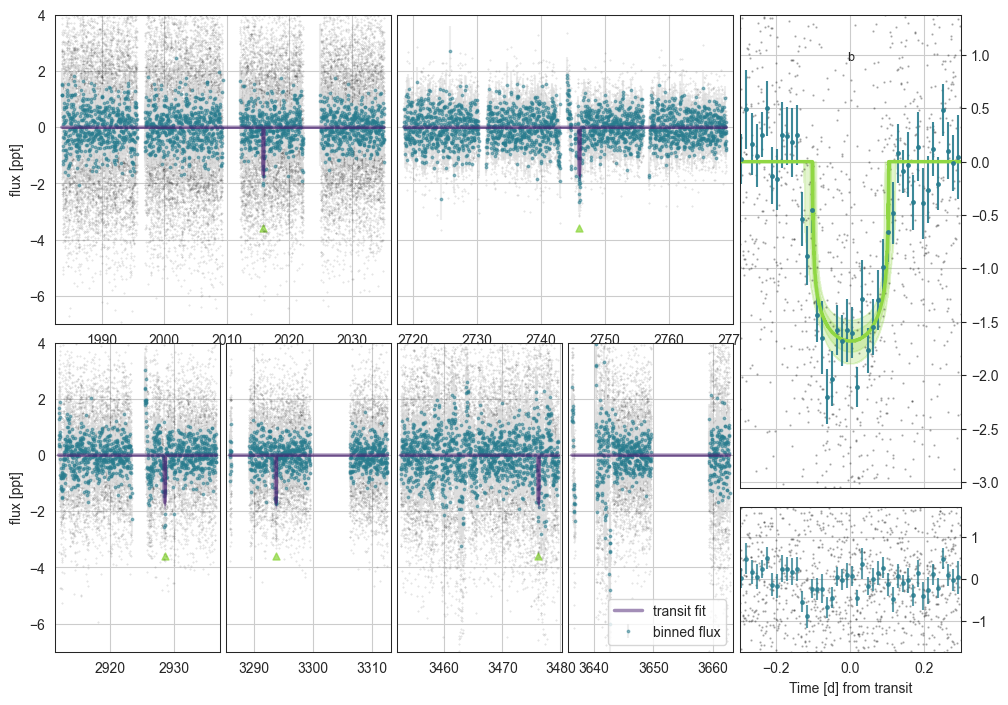

In [127]:
mod.plot(overwrite=True, ylim=(-7,4), xlim=(-0.3,0.3), plot_flat=True)

# Predicting future transits


In [130]:
mod.predict_future_transits()

time range 2025-05-22T10:27:09.630 -> 2025-11-18T10:27:09.633


,transit_mid_date,transit_mid_med,transit_dur_med,transit_dur_-1sig,transit_dur_+1sig,transit_start_+2sig,transit_start_+1sig,transit_start_med,transit_start_-1sig,transit_start_-2sig,...,planet_name,alias_n,alias_p,aliases_ns,aliases_ps,total_prob,num_aliases,in_TESS,sun_separation,moon_separation
0,2025-06-14T19:35:56.970,3841.316632,0.204842,0.198116,0.215877,3841.230801,3841.222288,3841.214211,3841.203897,3841.185052,...,duo_b,0,182.549693,"0,1,2,3,4","182.5497,91.2748,60.8499,45.6374,36.5099",1.000000,5.0,False,52.545917,118.162380
1,2025-07-21T07:50:16.117,3877.826575,0.204842,0.198116,0.215877,3877.740917,3877.732349,3877.724155,3877.713692,3877.694763,...,duo_b,4,36.509939,4,36.5099,0.402557,1.0,False,62.355785,47.446337
2,2025-07-30T10:53:51.233,3886.954065,0.204842,0.198116,0.215877,3886.868444,3886.859880,3886.851644,3886.841121,3886.822194,...,duo_b,3,45.637423,3,45.6374,0.305821,1.0,False,66.530400,107.730904
3,2025-08-14T15:59:47.930,3902.166527,0.204842,0.198116,0.215877,3902.081001,3902.072394,3902.064106,3902.053558,3902.034599,...,duo_b,2,60.849898,2,60.8499,0.213620,1.0,False,74.408624,62.086731
4,2025-08-26T20:04:34.972,3914.336516,0.204842,0.198116,0.215877,3914.251044,3914.242406,3914.234095,3914.223497,3914.204527,...,duo_b,4,36.509939,4,36.5099,0.402557,1.0,False,81.276866,108.117816
5,2025-09-14T02:11:44.635,3932.591489,0.204842,0.198116,0.215877,3932.506126,3932.497435,3932.489068,3932.478400,3932.459408,...,duo_b,1,91.274847,"1,3","91.2748,45.6374",0.378563,2.0,False,92.032026,47.045340
6,2025-10-02T08:18:56.251,3950.846484,0.204842,0.198116,0.215877,3950.761209,3950.752463,3950.744064,3950.733351,3950.714259,...,duo_b,4,36.509939,4,36.5099,0.402557,1.0,False,102.766891,116.910797
7,2025-10-14T12:23:44.020,3963.016482,0.204842,0.198116,0.215877,3962.931264,3962.922486,3962.914061,3962.903287,3962.884185,...,duo_b,2,60.849898,2,60.8499,0.213620,1.0,False,109.556050,59.926603
8,2025-10-29T17:29:43.320,3978.228974,0.204842,0.198116,0.215877,3978.143824,3978.135002,3978.126553,3978.115736,3978.096591,...,duo_b,3,45.637423,3,45.6374,0.305821,1.0,False,117.172339,116.540551
9,2025-11-07T20:33:18.207,3987.356461,0.204842,0.198116,0.215877,3987.271363,3987.262493,3987.254040,3987.243183,3987.224035,...,duo_b,4,36.509939,4,36.5099,0.402557,1.0,False,121.023279,47.250743


variables for Corner: ['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b']
['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b']


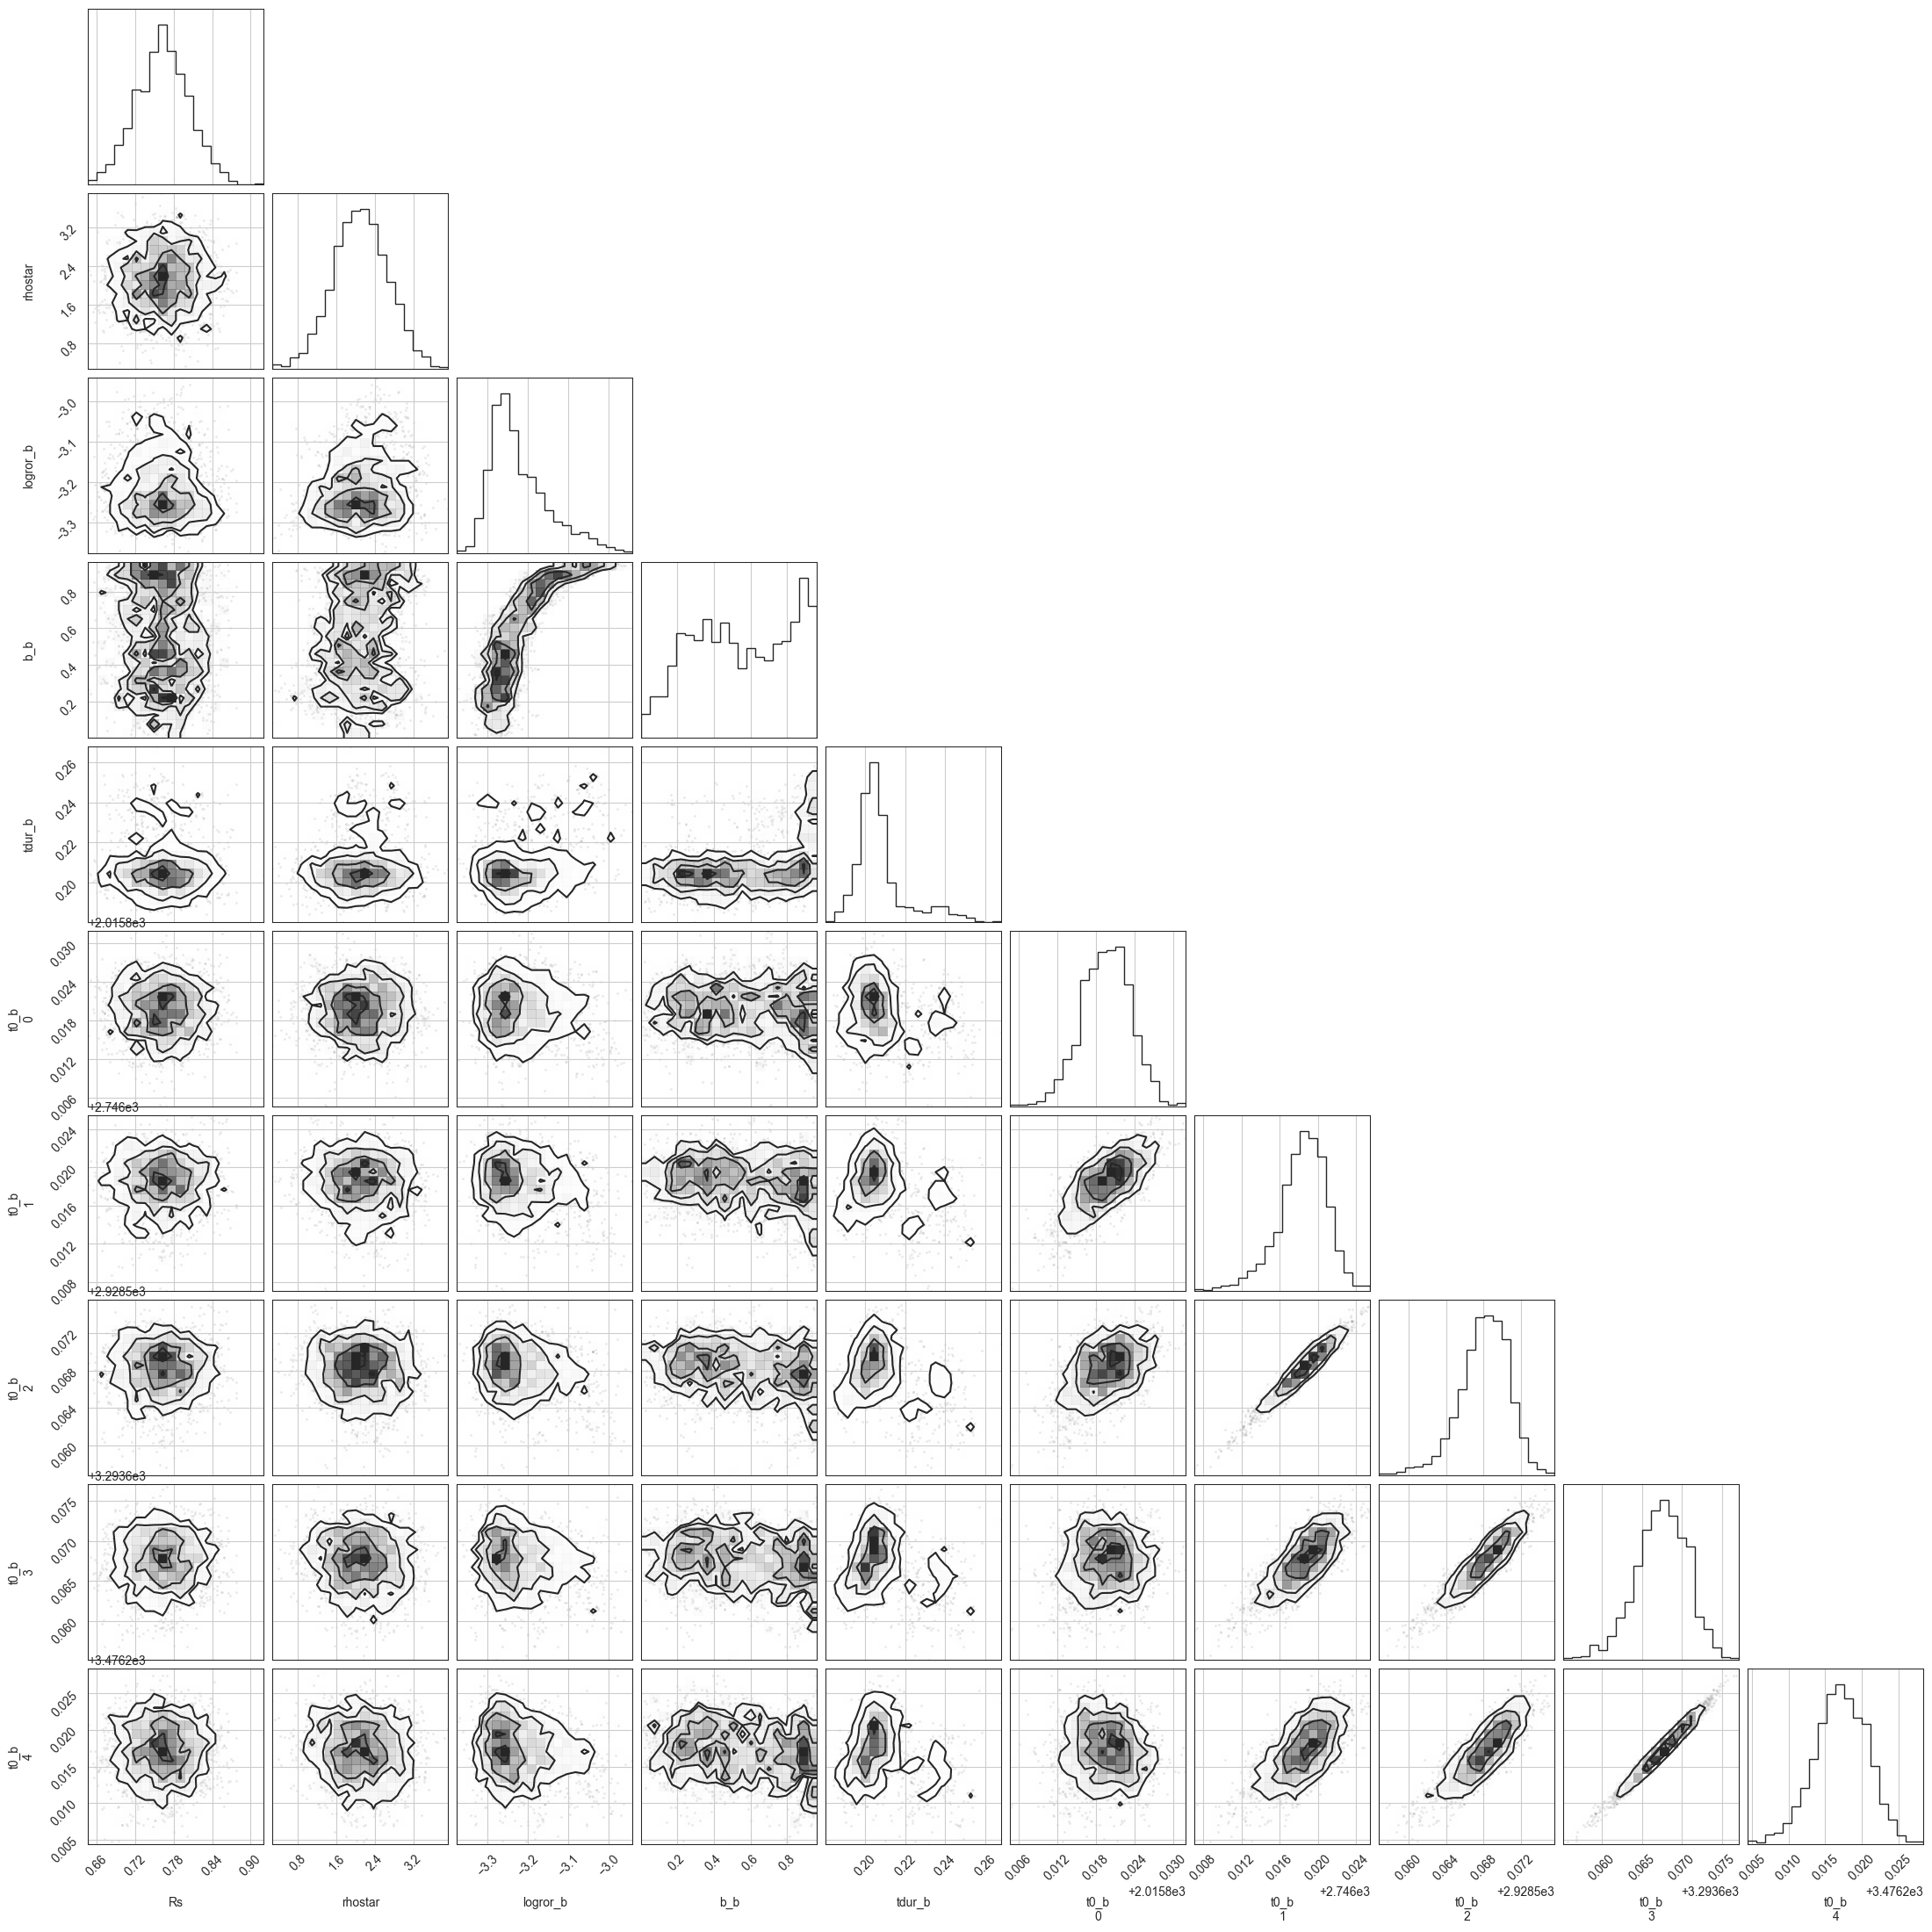

In [137]:
mod.plot_corner()

In [74]:
df=mod.make_table()
df

Saving sampled model parameters to file with shape:  (84, 14)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
Rs,0.75914,0.03932,0.68555,0.83545,0.00245,0.00173,256.57139,554.02383,1.01865,0.69458,0.72013,0.75909,0.79827,0.82624
rhostar,2.11344,0.51435,1.10447,3.04547,0.04724,0.03348,118.95985,376.04896,1.03987,1.26015,1.58644,2.11278,2.62271,2.95344
t0_b_0,2015.81954,0.00361,2015.81227,2015.82586,0.00033,0.00023,125.08518,257.33884,1.02911,2015.81328,2015.81581,2015.81980,2015.82304,2015.82509
t0_b_4,3476.21778,0.00349,3476.21136,3476.22438,0.00036,0.00026,88.44852,137.51605,1.01490,3476.21187,3476.21431,3476.21795,3476.22126,3476.22334
logror_b,-3.23370,0.07041,-3.34304,-3.08708,0.00847,0.00602,63.27842,220.54433,1.05399,-3.32226,-3.29658,-3.24998,-3.16546,-3.09006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ecc_marg_av_b,0.28329,0.17512,0.07252,0.68004,0.01778,0.01332,133.69406,126.64398,1.02903,0.11189,0.14021,0.22851,0.43020,0.68658
ecc_marg_sd_b,0.01114,0.00675,0.00362,0.02319,0.00037,0.00026,283.91514,1264.14921,1.01527,0.00478,0.00628,0.00901,0.01577,0.02457
vel_marg_b,0.90226,0.20179,0.41050,1.18413,0.02781,0.01995,49.53510,126.64398,1.07933,0.47677,0.71542,0.96573,1.04469,1.17609
per_marg_av_b,52.17087,7.82383,40.16136,64.05983,0.94241,0.66923,77.30736,849.53915,1.03951,41.37299,42.45703,53.81017,59.11554,64.13437
